In [68]:
# dripyto# install basical image libs
!pip install Pillow>=5.0.0
!pip install -U image
!pip install wheel

# install torch and torchvision (a utility library for computer vision that provides many public datasets and pre-trained models)
!pip install torch torchvision

In [94]:
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
cuda0 = torch.device('cuda:0')  # pick the GPU at index 0

import torchvision

import PIL
import matplotlib.pyplot as plt

In [95]:
from torchvision.datasets import CIFAR10
train_set = CIFAR10(root='data/', download=True)
len(train_set)
val_set = CIFAR10(root='data/', train=False)
len(val_set)


10000

In [97]:
image = train_set[132][0]
label = train_set[132][1]

#image, label = train_set[132]
print('Label {}:'.format(label))
#print(image.size())
print(image)

Label 6:
<PIL.Image.Image image mode=RGB size=32x32 at 0x7B76500245C0>


In [98]:
transform = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(mean=(0.5,), std=(0.5,)),  # [0, 1] range => [-1, 1] range
])

train_set = torchvision.datasets.CIFAR10(root='./data', download=False, train=True,
                                         transform=transform)
val_set = torchvision.datasets.CIFAR10(root='./data', download=False, train=False,
                                         transform=transform)

In [99]:
# loaders

batch_size = 512

train_loader = torch.utils.data.DataLoader(train_set,
                                           batch_size=batch_size,
                                           shuffle=True,                   # shuffle training set
                                           num_workers=2,                  # turns on multi-processing loading so training is not blocked by data loading
                                           pin_memory=True)                # pin_memory allows faster transfer from CPU to GPU
val_loader = torch.utils.data.DataLoader(val_set,
                                         batch_size=batch_size,
                                         num_workers=2,
                                         pin_memory=True)

In [100]:
class MyNet(nn.Module):
    def __init__(self):
        super(MyNet, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=6, kernel_size=5, padding=2)
        self.conv2 = nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5)
        self.fc1 = nn.Linear(in_features=16 * 6 * 6, out_features=120)
        self.fc2 = nn.Linear(in_features=120, out_features=84)
        self.fc3 = nn.Linear(in_features=84, out_features=10)

    def forward(self, x):
        out = F.relu(self.conv1(x))
        out = F.max_pool2d(out, 2)
        out = F.relu(self.conv2(out))
        out = F.max_pool2d(out, 2)
        out = out.reshape(out.size(0), -1)
        out = F.relu(self.fc1(out))
        out = F.relu(self.fc2(out))
        out = self.fc3(out)
        return out



In [101]:
net = MyNet().to(cuda0)

In [102]:
# This network output a size 10 vector for each input image, as verified below
# using a random input tensor.
# IT IS VERY IMPORTANT THAT YOUR NETWORK PASSES THIS TEST
# The CIFAR images are 32x32 with 3 channels

random_input = torch.randn(123, 3, 32, 32, device=cuda0) # was 28, 28
output = net(random_input)
print(output.shape)

torch.Size([123, 10])


In [103]:
# Training loop
def train(net, optim, train_loader):
    net.train()
    total_loss = 0
    num_batches = 0
    for image_cpu, label_cpu in train_loader:
        # put data onto GPU
        image = image_cpu.to(cuda0)
        label = label_cpu.to(cuda0)

        # TODO: complete this function
        # clear gradient
        optim.zero_grad()

        # forward through the network
        output = net(image)

        # compute loss and gradient
        loss = F.cross_entropy(output, label)
        loss.backward()

        # update parameters
        optim.step()

        total_loss += loss.item()
        num_batches += 1

    return total_loss / num_batches

In [104]:
# Evaluation on validation set
def evaluate(net):
    total = 0
    correct = 0

    net.eval()  # puts the network in eval mode. this is important when the
                # network has layers that behave differently in training and
                # evaluation time, e.g., dropout and batch norm.
    for image_cpu, label_cpu in val_loader:
        # put data onto GPU
        image = image_cpu.to(cuda0)
        label = label_cpu.to(cuda0)

        with torch.no_grad():  # gradients are not tracked in this context manager
                               # since we are evaluating, gradients are not needed
                               # and we can save some time and GPU memory.

            # forward through the network, and get the predicted class
            prediction = net(image).argmax(dim=-1)

            total += image.size(0)  # batch size
            correct += (prediction == label).sum().item()  # `.item()` retreives a python number from a 1-element tensor

    return correct / total

In [106]:
# main
num_epochs = 20
lr = .1

train_losses = []
val_accuracies = []

optim = torch.optim.SGD(net.parameters(), lr=lr, momentum=0.9)

for epoch in range(num_epochs):
    # Evaluate before training
    val_acc = evaluate(net) * 100
    val_accuracies.append(val_acc)

    # Train for one epoch and get loss
    train_loss = train(net, optim, train_loader)
    train_losses.append(train_loss)

    print('Epoch: {}\tTrain Loss: {:.4f}\tValidation Accuracy: {:.4f}%'.format(epoch, train_loss, val_acc))
    train(net, optim, train_loader)

# Final evaluation
final_acc = evaluate(net) * 100
val_accuracies.append(final_acc)

print('Done! \tValidation Accuracy: {:.4f}%'.format(evaluate(net) * 100))

Epoch: 0	Train Loss: 2.0759	Validation Accuracy: 10.0000%
Epoch: 1	Train Loss: 1.2766	Validation Accuracy: 52.0900%
Epoch: 2	Train Loss: 1.0455	Validation Accuracy: 61.1500%
Epoch: 3	Train Loss: 0.8880	Validation Accuracy: 62.0900%
Epoch: 4	Train Loss: 0.7839	Validation Accuracy: 64.0900%
Epoch: 5	Train Loss: 0.7095	Validation Accuracy: 64.3300%
Epoch: 6	Train Loss: 0.6528	Validation Accuracy: 65.0600%
Epoch: 7	Train Loss: 0.5813	Validation Accuracy: 64.3400%
Epoch: 8	Train Loss: 0.5298	Validation Accuracy: 63.9600%
Epoch: 9	Train Loss: 0.5164	Validation Accuracy: 63.2900%
Epoch: 10	Train Loss: 0.4844	Validation Accuracy: 63.5000%
Epoch: 11	Train Loss: 0.4472	Validation Accuracy: 61.2300%
Epoch: 12	Train Loss: 0.4317	Validation Accuracy: 62.3900%
Epoch: 13	Train Loss: 0.4296	Validation Accuracy: 61.9500%
Epoch: 14	Train Loss: 0.4113	Validation Accuracy: 61.9100%
Epoch: 15	Train Loss: 0.3870	Validation Accuracy: 62.1600%
Epoch: 16	Train Loss: 0.3886	Validation Accuracy: 61.6300%
Epoch: 

label is 6


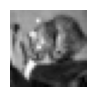

predicted class is 4


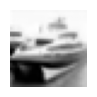

predicted class is 8


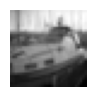

predicted class is 1


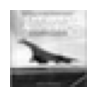

predicted class is 0


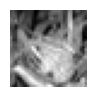

predicted class is 4


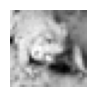

predicted class is 6


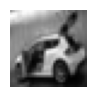

predicted class is 1


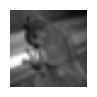

predicted class is 6


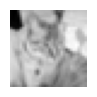

predicted class is 5


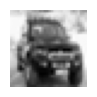

predicted class is 1


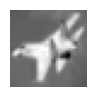

predicted class is 5


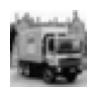

predicted class is 9


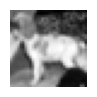

predicted class is 2


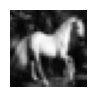

predicted class is 7


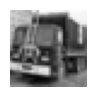

predicted class is 9


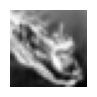

predicted class is 8


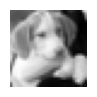

predicted class is 5


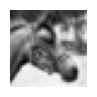

predicted class is 7


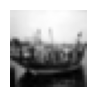

predicted class is 8


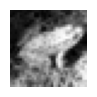

predicted class is 6


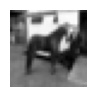

predicted class is 7


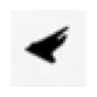

predicted class is 0


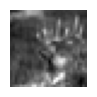

predicted class is 2


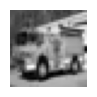

predicted class is 9


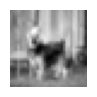

predicted class is 2


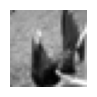

predicted class is 4


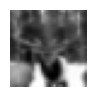

predicted class is 5


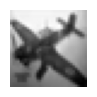

predicted class is 0


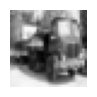

predicted class is 9


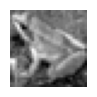

predicted class is 6


In [107]:
# Utility function
def tensor2image(tensor):
    return PIL.Image.fromarray((tensor.detach() * 127.5 + 128).clamp_(0, 255).to('cpu', torch.uint8).numpy()[0])

# Get a data sample we want to attack

data, label = val_set[30]
data = data.to(cuda0)

# Look at the image
tensor2image(data)

# Label is...
print('label is', label)


for i in range(30):
    # Get a data sample we want to attack

    data, label = val_set[i]
    data = data.to(cuda0)
    # Look at the image

    plt.figure(figsize=(1,1))
    plt.imshow(tensor2image(data), cmap='gray')
    plt.axis('off')
    plt.show()

    # turn the network into eval mode
    net.eval()
    output = net(data.unsqueeze(0))  # .unsqueeze(0) insert a batch dimension so it looks like batched data
    prediction = output.argmax(-1)
    print('predicted class is', prediction.item())

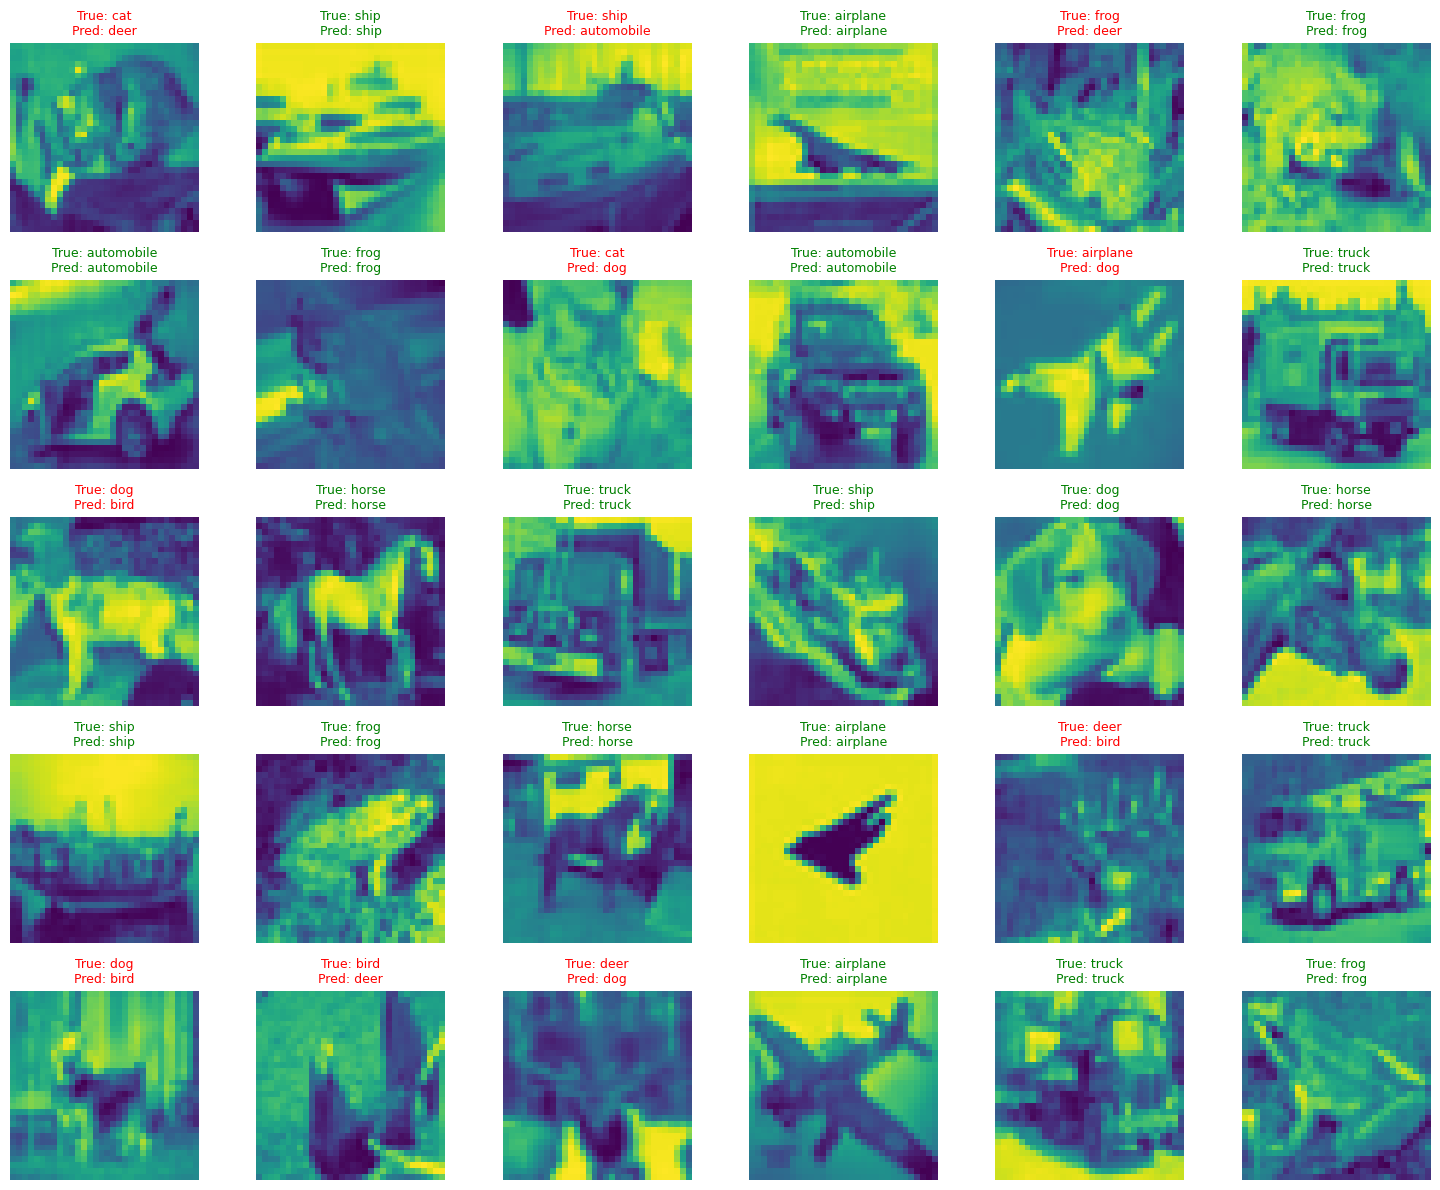


✓ Notebook execution complete!


In [108]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

fig, axes = plt.subplots(5, 6, figsize=(15, 12))
axes = axes.flatten()

net.eval()
for i in range(30):
    data, label = val_set[i]
    data_gpu = data.to(cuda0)

    # Predict
    with torch.no_grad():
        output = net(data_gpu.unsqueeze(0))
        prediction = output.argmax(-1).item()

    # Plot
    axes[i].imshow(tensor2image(data))
    axes[i].axis('off')

    color = 'green' if prediction == label else 'red'
    axes[i].set_title(f'True: {class_names[label]}\nPred: {class_names[prediction]}',
                      fontsize=9, color=color)

plt.tight_layout()
plt.show()



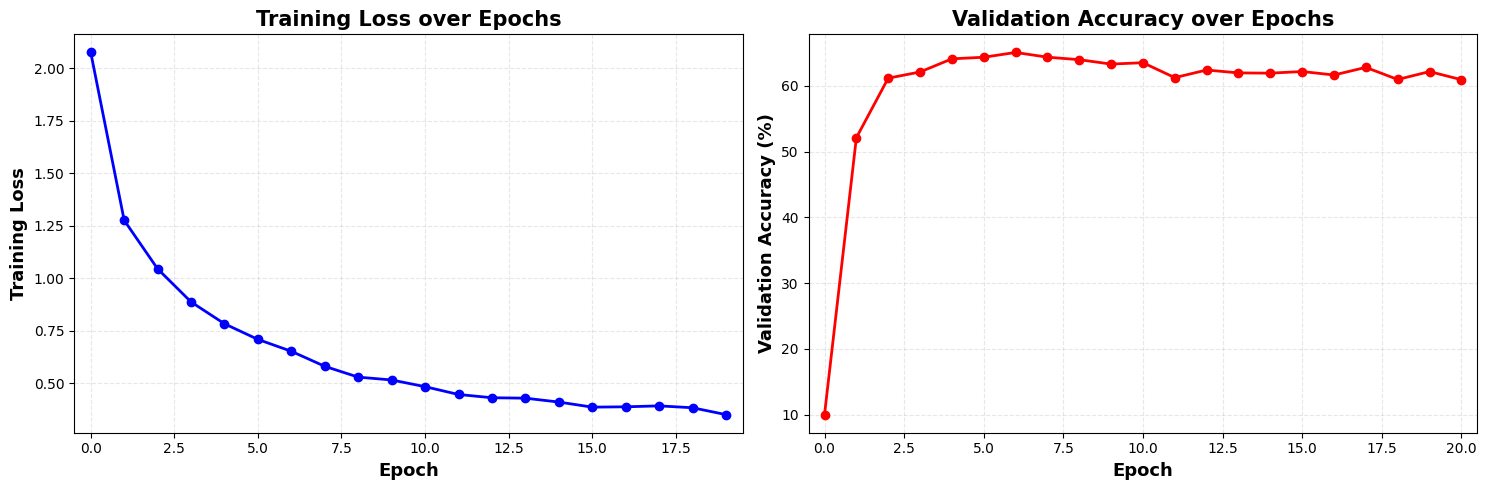


TRAINING SUMMARY
Initial Validation Accuracy: 10.00%
Final Validation Accuracy:   60.92%
Improvement:                 50.92%

Initial Training Loss:       2.0759
Final Training Loss:         0.3514
Loss Reduction:              1.7245


In [109]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot training loss
ax1.plot(range(len(train_losses)), train_losses, 'b-o', linewidth=2, markersize=6)
ax1.set_xlabel('Epoch', fontsize=13, fontweight='bold')
ax1.set_ylabel('Training Loss', fontsize=13, fontweight='bold')
ax1.set_title('Training Loss over Epochs', fontsize=15, fontweight='bold')
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.set_xlim(-0.5, len(train_losses)-0.5)

# Plot validation accuracy
ax2.plot(range(len(val_accuracies)), val_accuracies, 'r-o', linewidth=2, markersize=6)
ax2.set_xlabel('Epoch', fontsize=13, fontweight='bold')
ax2.set_ylabel('Validation Accuracy (%)', fontsize=13, fontweight='bold')
ax2.set_title('Validation Accuracy over Epochs', fontsize=15, fontweight='bold')
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.set_xlim(-0.5, len(val_accuracies)-0.5)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n" + "="*70)
print("TRAINING SUMMARY")
print("="*70)
print(f"Initial Validation Accuracy: {val_accuracies[0]:.2f}%")
print(f"Final Validation Accuracy:   {val_accuracies[-1]:.2f}%")
print(f"Improvement:                 {val_accuracies[-1] - val_accuracies[0]:.2f}%")
print(f"\nInitial Training Loss:       {train_losses[0]:.4f}")
print(f"Final Training Loss:         {train_losses[-1]:.4f}")
print(f"Loss Reduction:              {train_losses[0] - train_losses[-1]:.4f}")
print("="*70)


In [110]:
def create_subset_loader(dataset, fraction, batch_size):
    """Create a dataloader with only a fraction of the data"""
    subset_size = int(len(dataset) * fraction)
    indices = torch.randperm(len(dataset))[:subset_size]
    subset = torch.utils.data.Subset(dataset, indices)

    loader = torch.utils.data.DataLoader(subset,
                                         batch_size=batch_size,
                                         shuffle=True,
                                         num_workers=2,
                                         pin_memory=True)
    return loader

In [112]:
data_fractions = [0.5, 0.25, 0.1]
results = {}

for fraction in data_fractions:
    print(f"\n{'='*60}")
    print(f"Training with {int(fraction*100)}% of data")
    print(f"{'='*60}")

    # Create subset loader
    if fraction == 1.0:
        current_loader = train_loader
    else:
        current_loader = create_subset_loader(train_set, fraction, batch_size)

    # Reinitialize network
    net_temp = MyNet().to(cuda0)
    optim_temp = torch.optim.SGD(net_temp.parameters(), lr=lr, momentum=0.9)

    # Train for fewer epochs for subsets
    epochs = 10

    for epoch in range(epochs):
        if epoch % 2 == 0:
            val_acc = evaluate(net_temp) * 100
            print(f'Epoch: {epoch}\tValidation Accuracy: {val_acc:.2f}%')
        train(net_temp, optim_temp, current_loader)

    # Final accuracy
    final_acc = evaluate(net_temp) * 100
    results[fraction] = final_acc
    print(f'Final Validation Accuracy: {final_acc:.2f}%')


Training with 50% of data
Epoch: 0	Validation Accuracy: 10.06%
Epoch: 2	Validation Accuracy: 29.70%
Epoch: 4	Validation Accuracy: 38.72%
Epoch: 6	Validation Accuracy: 44.92%
Epoch: 8	Validation Accuracy: 48.23%
Final Validation Accuracy: 48.95%

Training with 25% of data
Epoch: 0	Validation Accuracy: 10.00%
Epoch: 2	Validation Accuracy: 29.41%
Epoch: 4	Validation Accuracy: 44.19%
Epoch: 6	Validation Accuracy: 47.50%
Epoch: 8	Validation Accuracy: 48.86%
Final Validation Accuracy: 52.19%

Training with 10% of data
Epoch: 0	Validation Accuracy: 8.68%
Epoch: 2	Validation Accuracy: 15.92%
Epoch: 4	Validation Accuracy: 26.48%
Epoch: 6	Validation Accuracy: 34.07%
Epoch: 8	Validation Accuracy: 36.74%
Final Validation Accuracy: 43.14%
